# Forward and Backpropagation using TensorFlow/Keras
Ready to run in Google Colab.

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.datasets import imdb

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)
x_train=x_train.reshape(-1,784)/255.0
x_test=x_test.reshape(-1,784)/255.0
def create_model(lr):
    m=Sequential([Dense(128,activation='relu',input_shape=(784,)),
                  Dense(64,activation='relu'),
                  Dense(10,activation='softmax')])
    m.compile(optimizer=Adam(learning_rate=lr),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
learning_rates=[0.1,0.01,0.001]
results=[]
for lr in learning_rates:
    model=create_model(lr)
    model.fit(x_train,y_train,epochs=5,batch_size=128,verbose=0)
    loss,acc=model.evaluate(x_test,y_test,verbose=0)
    results.append([lr,acc])
df=pd.DataFrame(results,columns=['Learning Rate','Accuracy'])
print(df)
plt.plot(df['Learning Rate'],df['Accuracy'],marker='o')
plt.xscale('log'); plt.grid(); plt.show()


ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 60000
'y' sizes: 25000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Epochs  Accuracy
0       5    0.9726
1      10    0.9756
2      20    0.9725


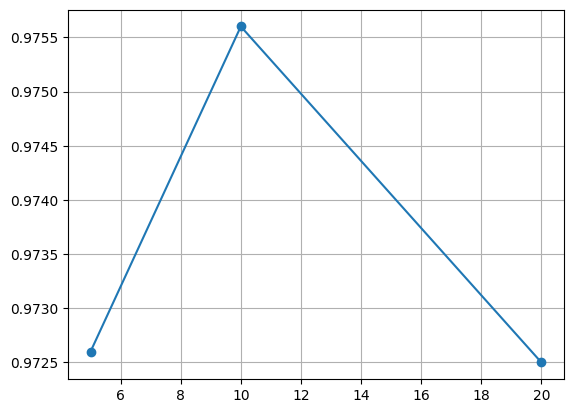

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8980 - loss: 0.3630 - val_accuracy: 0.9449 - val_loss: 0.1823
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9567 - loss: 0.1482 - val_accuracy: 0.9596 - val_loss: 0.1341
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9690 - loss: 0.1023 - val_accuracy: 0.9659 - val_loss: 0.1113
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9770 - loss: 0.0777 - val_accuracy: 0.9684 - val_loss: 0.0986
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9818 - loss: 0.0605 - val_accuracy: 0.9718 - val_loss: 0.0924
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9860 - loss: 0.0472 - val_accuracy: 0.9711 - val_loss: 0.0977
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9887 - loss: 0.0387 - val_accuracy: 0.9710 - val_loss: 0.0971
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9900 - loss: 0.0326 - val_accuracy: 0.9724 - val_

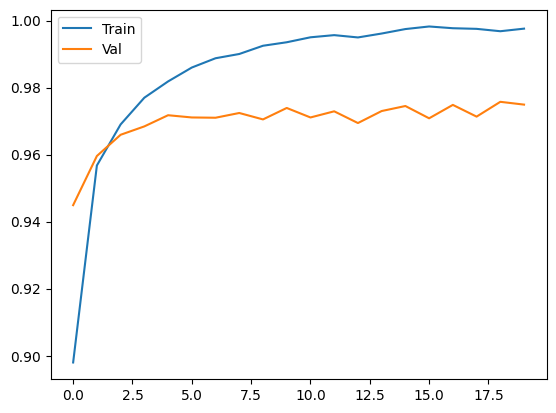

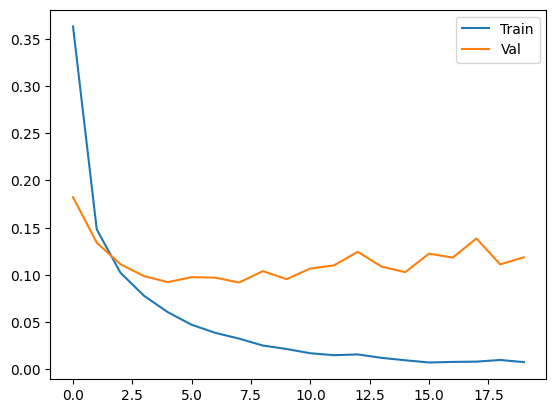

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9739 - loss: 0.1145
[0.11454229801893234, 0.9739000201225281]


In [3]:
epochs_list=[5,10,20]
res=[]
for ep in epochs_list:
    model=create_model(0.001)
    h=model.fit(x_train,y_train,validation_split=0.2,epochs=ep,batch_size=128,verbose=0)
    loss,acc=model.evaluate(x_test,y_test,verbose=0)
    res.append([ep,acc])
edf=pd.DataFrame(res,columns=['Epochs','Accuracy'])
print(edf)
plt.plot(edf['Epochs'],edf['Accuracy'],marker='o')
plt.grid(); plt.show()

model=create_model(0.001)
history=model.fit(x_train,y_train,validation_split=0.2,epochs=20,batch_size=128)
plt.plot(history.history['accuracy']); plt.plot(history.history['val_accuracy']); plt.legend(['Train','Val']); plt.show()
plt.plot(history.history['loss']); plt.plot(history.history['val_loss']); plt.legend(['Train','Val']); plt.show()
print(model.evaluate(x_test,y_test))


In [9]:
# ==============================
# Import Libraries
# ==============================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import cifar10

import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# Load Dataset
# ==============================
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Flatten images and Normalize
x_train = x_train.reshape(-1, 32*32*3).astype("float32") / 255.0
x_test = x_test.reshape(-1, 32*32*3).astype("float32") / 255.0

# Convert labels to 1-D
y_train = y_train.flatten()
y_test = y_test.flatten()

# ==============================
# Create Model
# ==============================
def create_model(lr):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(3072,)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# ==============================
# Effect of Learning Rate
# ==============================
learning_rates = [0.1, 0.01, 0.001]
results = []

for lr in learning_rates:

    model = create_model(lr)

    model.fit(
        x_train,
        y_train,
        epochs=5,
        batch_size=128,
        verbose=0
    )

    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    results.append([lr, acc])

df = pd.DataFrame(results, columns=['Learning Rate', 'Accuracy'])

print("\nLearning Rate Comparison")
print(df)

plt.figure(figsize=(6,4))
plt.plot(df['Learning Rate'], df['Accuracy'], marker='o')
plt.xscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Learning Rate vs Accuracy")
plt.grid(True)
plt.show()


# ==============================
# Effect of Epochs
# ==============================
epochs_list = [5, 10, 20]
results = []

for ep in epochs_list:

    model = create_model(0.001)

    model.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=ep,
        batch_size=128,
        verbose=0
    )

    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    results.append([ep, acc])

epoch_df = pd.DataFrame(results, columns=['Epochs', 'Accuracy'])

print("\nEpoch Comparison")
print(epoch_df)

plt.figure(figsize=(6,4))
plt.plot(epoch_df['Epochs'], epoch_df['Accuracy'], marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Epochs vs Accuracy")
plt.grid(True)
plt.show()


# ==============================
# Final Training
# ==============================
model = create_model(0.001)

history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    verbose=1
)


# ==============================
# Accuracy Graph
# ==============================
plt.figure(figsize=(7,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# ==============================
# Loss Graph
# ==============================
plt.figure(figsize=(7,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


# ==============================
# Final Evaluation
# ==============================
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)

print("\nFinal Model Performance")
print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

   450560/170498071 ━━━━━━━━━━━━━━━━━━━━ 1:20:02 28us/step

KeyboardInterrupt: 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


   Learning Rate  Accuracy
0          0.100   0.49996
1          0.010   0.85796
2          0.001   0.87764


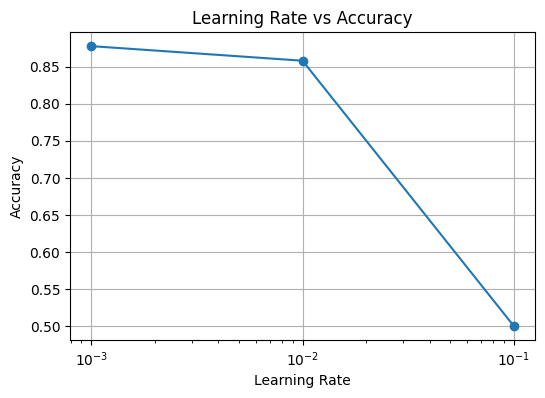

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


   Epochs  Accuracy
0       5   0.87496
1      10   0.87160
2      20   0.83788


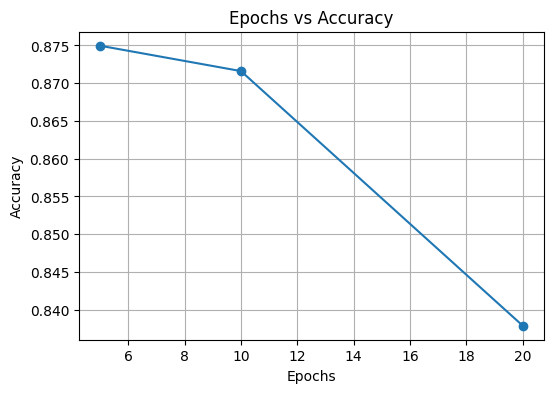

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6866 - loss: 0.6455 - val_accuracy: 0.7678 - val_loss: 0.5443
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8368 - loss: 0.4311 - val_accuracy: 0.8524 - val_loss: 0.3655
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8795 - loss: 0.3089 - val_accuracy: 0.8702 - val_loss: 0.3156
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8999 - loss: 0.2596 - val_accuracy: 0.8796 - val_loss: 0.2976
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9111 - loss: 0.2274 - val_accuracy: 0.8822 - val_loss: 0.2898
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9251 - loss: 0.1997 - val_accuracy: 0.8680 - val_loss: 0.3087
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9299 - loss: 0.1844 - val_accuracy: 0.8842 - val_loss: 0.2911
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9384 - loss: 0.1692 - val_accuracy: 0.8758

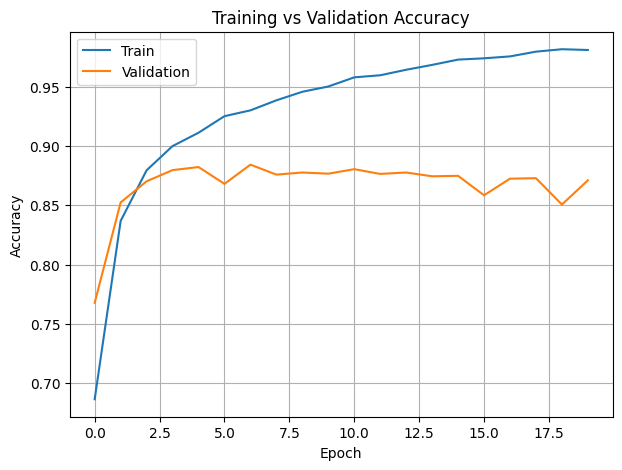

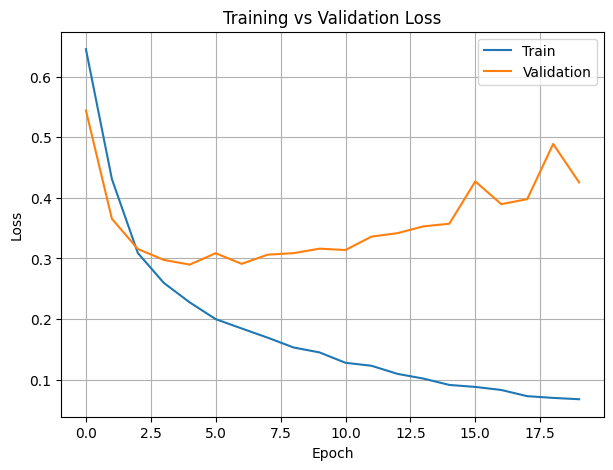


Final Test Loss : 0.4759593605995178
Final Test Accuracy : 0.8563200235366821


In [10]:
# ==========================
# Import Libraries
# ==========================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# Load Dataset
# ==========================
vocab_size = 10000
max_length = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Pad sequences to equal length
x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

# ==========================
# Create Model
# ==========================
def create_model(lr):

    model = Sequential([
        Embedding(vocab_size, 32, input_length=max_length),
        GlobalAveragePooling1D(),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# ==========================
# Effect of Learning Rate
# ==========================
learning_rates = [0.1, 0.01, 0.001]

results = []

for lr in learning_rates:

    model = create_model(lr)

    model.fit(
        x_train,
        y_train,
        epochs=5,
        batch_size=128,
        verbose=0
    )

    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    results.append([lr, acc])

df = pd.DataFrame(results,
                  columns=["Learning Rate", "Accuracy"])

print(df)

plt.figure(figsize=(6,4))
plt.plot(df["Learning Rate"],
         df["Accuracy"],
         marker='o')

plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Learning Rate vs Accuracy")
plt.grid(True)
plt.show()

# ==========================
# Effect of Epochs
# ==========================
epochs_list = [5, 10, 20]

results = []

for ep in epochs_list:

    model = create_model(0.001)

    model.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=ep,
        batch_size=128,
        verbose=0
    )

    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    results.append([ep, acc])

epoch_df = pd.DataFrame(results,
                        columns=["Epochs", "Accuracy"])

print(epoch_df)

plt.figure(figsize=(6,4))
plt.plot(epoch_df["Epochs"],
         epoch_df["Accuracy"],
         marker='o')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Epochs vs Accuracy")
plt.grid(True)
plt.show()

# ==========================
# Final Model Training
# ==========================
model = create_model(0.001)

history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    verbose=1
)

# ==========================
# Accuracy Graph
# ==========================
plt.figure(figsize=(7,5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend(["Train","Validation"])

plt.grid(True)
plt.show()

# ==========================
# Loss Graph
# ==========================
plt.figure(figsize=(7,5))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend(["Train","Validation"])

plt.grid(True)
plt.show()

# ==========================
# Final Evaluation
# ==========================
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)

print("\nFinal Test Loss :", loss)
print("Final Test Accuracy :", accuracy)